# **Portfolio Allocation with a Carbon Objective**

**Course:** Sustainability Aware Asset Management (SAAM)

**Semester:** Spring 2025-2026

**Teacher:** Éric Jondeau

**Teaching assistant:** Yao Li

**Authors:** 

Alessandro Botti (25444829)

Yoann Klingele (22401947)

Charbel Merhi (n° student)

Andrea Perani (n° student)


This notebook supports the PDF report by implementing the empirical analysis in Python.

## **Reproducibility**

To ensure the reproducibility of the analysis, please follow the steps outlined below:

- Clone the project repository locally

- Create and activate the required Python environment:

```bash
     conda env create -f environment.yml
     conda activate saam-project
```

- Select the corresponding environment as the notebook kernel

- Run all cells from top to bottom

## **Part I – Standard Portfolio Allocation**

The first part of the project consists of building a **minimum-variance portfolio** and evaluating its performance against a **value-weighted benchmark**.


In [156]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [157]:
#Path to the cleaned datasets
path = "../data/cleaned/"

#Load the cleaned datasets
static = pd.read_csv(path + "STATIC_cleaned.csv", sep=";", na_values="N/A")
co2 = pd.read_csv(path + "CO2_S1_cleaned.csv", sep=";", na_values="N/A")
ri_m = pd.read_csv(path + "RI_M_cleaned.csv", sep=";", na_values="N/A")

### **1) Data Cleaning**

Some data cleaning was necessary to design an investment strategy that is both meaningful and implementable.

The datasets used in this notebook are Excel-cleaned versions of the original Datastream outputs:

- **CO2_S1_cleaned.csv** : Scope 1 CO2 emissions (annual) (in tonnes)

- **REVENUE_Y_cleaned.csv** : Revenues (annual) (in thousands USD)

- **MV_M_cleaned.csv** :  Market capitalization (end of month) (in million USD)

- **MV_Y_cleaned.csv** :  Market capitalization (end of year) (in million USD)

- **RI_M_cleaned.csv** : Total return index (price index, including dividend payments) (end of month)

- **RI_Y_cleaned.csv** : Total return index (price index, including dividend payments) (end of year)

- **RF.csv** : Risk free (monthly)

- **STATIC_cleaned.csv** : Firms (ISIN, Name, Country, Region)

The main cleaning issues addressed according to the project instructions are listed below:

- **Group investment strategy**

- **Missing revenue and CO2 emissions data**

- **Missing prices**

- **Missing values**

- **Low prices**

Further data cleaning is carried out in *Section 2.1* when defining the investment set.

A more detailed description of the full cleaning procedure is provided in the report.

The chart and table below show the firms remaining after the initial cleaning steps:

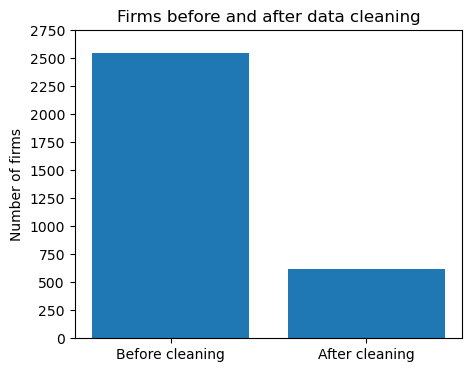

Firms after data cleaning: 618


,ISIN,NAME,Country,Region
0,AT000000STR1,STRABAG SE,AT,EUR
1,AT00000VIE62,FLUGHAFEN WIEN,AT,EUR
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR
615,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,IL,EUR
616,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,EUR
617,US91822M5022,VEON ADR 1:25,NL,EUR


In [158]:
#Firms before and after data cleaning
firms_before_cleaning = 2545
firms_after_cleaning = static.shape[0]

plt.figure(figsize=(5, 4))
plt.bar(
    ["Before cleaning", "After cleaning"],
    [firms_before_cleaning, firms_after_cleaning]
)

plt.ylabel("Number of firms")
plt.title("Firms before and after data cleaning")

#Add more y-axis values
plt.yticks(range(0, 2751, 250))

plt.show()

print("Firms after data cleaning:", firms_after_cleaning)
pd.concat([static.head(3), static.tail(3)])

In [159]:
#CO2 data after data cleaning
print("CO2:", co2.shape)
pd.concat([co2.head(3), co2.tail(3)])

CO2: (618, 29)


,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246,876651,844209,833816,742063,771799,813242,819934,790336,790336
1,FLUGHAFEN WIEN,AT00000VIE62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796,8455,8958,9648,4745,5663,7567,9027,9847,9847
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027,6270,7696,7455,6392,4827,6049,12403,9375,9375
615,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,US70211M1099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392,13392,5170,4833,3854,"4238,28",4569,4569,4569,4569
616,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,US8816242098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268,458755,372604,299146,290471,282044,253306,242056,243603,243603
617,VEON ADR 1:25,US91822M5022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,190000,230000,160000,160000,140000,100000,100000,100000,160000,160000


The CO2 dataset is converted to wide numeric format, using ISIN and NAME as firm identifiers: 

In [160]:
#Convert year labels to integers
co2_years = pd.to_numeric(co2.columns[2:], errors="raise").astype(int)

#Copy data and rename columns
co2_wide = co2.copy()
co2_wide.columns = ["NAME", "ISIN"] + list(co2_years)

#Set firm identifiers and sort years
co2_wide = co2_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

#Convert CO2 values to numeric format
co2_wide = co2_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("CO2_wide:", co2_wide.shape)
pd.concat([co2_wide.head(3), co2_wide.tail(3)])

CO2_wide: (618, 27)


,,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246.0,876651.0,844209.0,833816.0,742063.0,771799.00,813242.0,819934.0,790336.0,790336.0
AT00000VIE62,FLUGHAFEN WIEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796.0,8455.0,8958.0,9648.0,4745.0,5663.00,7567.0,9027.0,9847.0,9847.0
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027.0,6270.0,7696.0,7455.0,6392.0,4827.00,6049.0,12403.0,9375.0,9375.0
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392.0,13392.0,5170.0,4833.0,3854.0,4238.28,4569.0,4569.0,4569.0,4569.0
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268.0,458755.0,372604.0,299146.0,290471.0,282044.00,253306.0,242056.0,243603.0,243603.0
US91822M5022,VEON ADR 1:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,190000.0,230000.0,160000.0,160000.0,140000.0,100000.00,100000.0,100000.0,160000.0,160000.0


In [161]:
#RI_M data after data cleaning
print("RI_M:", ri_m.shape)
pd.concat([ri_m.head(3), ri_m.tail(3)])

RI_M: (618, 316)


,NAME,ISIN,31/12/1999,31/01/2000,29/02/2000,31/03/2000,28/04/2000,31/05/2000,30/06/2000,31/07/2000,...,30/04/2025,30/05/2025,30/06/2025,31/07/2025,29/08/2025,30/09/2025,31/10/2025,28/11/2025,31/12/2025,30/01/2026
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"430,27","430,83","479,46","477,35","465,06","461,5","396,65","452,87","481,49","526,88"
1,FLUGHAFEN WIEN,AT00000VIE62,"147,79","156,25","153,83","158,62","137,27","148,95","159,68","151,08",...,"2339,19","2371,03","2478,96","2417,14","2434,84","2425,66","2409,99","2533,4","2591,68","2587,67"
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"113,07","129,28","128,7","123,36","140,73","146,05","158,13","171,78","190,56","215,11"
615,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,US70211M1099,"159,82","113,5",105,"102,69","66,01","44,01","58,68","48,64",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
616,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,US8816242098,"1649,72","1506,25","1985,68","1718,26","2027,13","2483,16","2555,9","2801,43",...,"3867,12","4183,76","4178,77","3852,16","4582,69","5036,47","5106,29","6704,49","7781,6","8497,18"
617,VEON ADR 1:25,US91822M5022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"19,39","22,64","19,69","23,39","25,02","23,27","20,58","22,82","22,47","23,36"


The RI_M dataset is converted to wide numeric format, using ISIN and NAME as firm identifiers:

In [162]:
#Convert date labels to datetime format
date_labels = ri_m.columns[2:].astype(str).str.strip()
dates = pd.to_datetime(date_labels, format="%d/%m/%Y", errors="coerce")

#Copy data and rename columns
ri_m_wide = ri_m.copy()
ri_m_wide.columns = ["NAME", "ISIN"] + list(dates.date)

#Set firm identifiers and sort dates
ri_m_wide = ri_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

#Convert monthly return index values to numeric format
ri_m_wide = ri_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("RI_M_wide:", ri_m_wide.shape)
pd.concat([ri_m_wide.head(3), ri_m_wide.tail(3)])

RI_M_wide: (618, 314)


,,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,...,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88
AT00000VIE62,FLUGHAFEN WIEN,147.79,156.25,153.83,158.62,137.27,148.95,159.68,151.08,153.35,161.64,...,2339.19,2371.03,2478.96,2417.14,2434.84,2425.66,2409.99,2533.40,2591.68,2587.67
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,113.07,129.28,128.70,123.36,140.73,146.05,158.13,171.78,190.56,215.11
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,159.82,113.50,105.00,102.69,66.01,44.01,58.68,48.64,58.68,47.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,1649.72,1506.25,1985.68,1718.26,2027.13,2483.16,2555.90,2801.43,2796.27,3376.35,...,3867.12,4183.76,4178.77,3852.16,4582.69,5036.47,5106.29,6704.49,7781.60,8497.18
US91822M5022,VEON ADR 1:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19.39,22.64,19.69,23.39,25.02,23.27,20.58,22.82,22.47,23.36


### **2) Minimum-Variance Portfolio Allocation**

The monthly return index values are converted into returns using the simple return definition, $R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$.

Returns at date *t* are then collected in the vector $R_t = (R_{1,t}, \ldots, R_{N,t})$, where $N$ denotes the number of firms.

In [163]:
#Compute simple monthly returns from Return Index levels
returns_wide = ri_m_wide.pct_change(axis=1, fill_method=None)

print("Returns_wide:", returns_wide.shape)
pd.concat([returns_wide.head(3), returns_wide.tail(3)])

Returns_wide: (618, 314)


,,1999-12-31,2000-01-31,2000-02-29,2000-03-31,2000-04-28,2000-05-31,2000-06-30,2000-07-31,2000-08-31,2000-09-29,...,2025-04-30,2025-05-30,2025-06-30,2025-07-31,2025-08-29,2025-09-30,2025-10-31,2025-11-28,2025-12-31,2026-01-30
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,FLUGHAFEN WIEN,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,-0.289826,-0.074890,-0.022000,-0.357192,-0.333283,0.333333,-0.171097,0.206414,-0.190866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,-0.086966,0.318294,-0.134674,0.179757,0.224963,0.029293,0.096064,-0.001842,0.207448,...,0.009110,0.081880,-0.001193,-0.078159,0.189642,0.099020,0.013863,0.312987,0.160655,0.091958
US91822M5022,VEON ADR 1:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.040236,0.167612,-0.130300,0.187913,0.069688,-0.069944,-0.115599,0.108844,-0.015337,0.039608


#### **2.1) Investment Set**

To construct the out-of-sample portfolios, we first define the investment sets.

At the end of each year Y, the investment set for year Y+1 is formed by selecting the firms that satisfy the following criteria:

- **Sufficient number of return observations**

- **No excessive share of stale prices/zero returns**

- **CO2 emissions data availability**

- **Valid December Return Index observation**

Firms that fail to meet these criteria at the end of formation year Y are excluded from the portfolio for year Y+1.

As noted above, a more detailed description of the full cleaning procedure is provided in the report.

This cell defines the portfolio formation years, the main investment-set parameters, and the December dates used as formation dates: 

In [164]:
#Portfolio formation years: 2013-2024 (2025 is excluded)
years = range(2013, 2025)

#Investment-set parameters
tau = 120
min_obs = 36
stale_threshold = 0.50

#Portfolio formation dates
formation_dates = {}

for Y in years:
    december_dates = [d for d in returns_wide.columns if d.year == Y and d.month == 12]

    if len(december_dates) == 0:
        raise ValueError(f"No December date found for year {Y}")

    formation_dates[Y] = max(december_dates)

This cell defines the 120-month return window and the rules used to select eligible firms in each formation year: 

In [165]:
#120-month return window ending at the formation date
def get_formation_window(Y):
    formation_date = formation_dates[Y]
    end_loc = returns_wide.columns.get_loc(formation_date)
    start_loc = end_loc - tau + 1

    if start_loc < 0:
        raise ValueError(f"Not enough return history before {formation_date}")

    return returns_wide.iloc[:, start_loc:end_loc + 1]


#Define the investment set for formation year Y
def get_investment_set(Y, formation_window):
    formation_date = formation_dates[Y]

    #1)Sufficient number of return observations
    n_available = formation_window.notna().sum(axis=1)
    enough_history = n_available >= min_obs

    #2)No excessive share of stale prices/zero returns
    zero_share = formation_window.eq(0).sum(axis=1) / n_available
    not_stale = zero_share <= stale_threshold

    #3)CO2 emissions data availability
    has_carbon = co2_wide[Y].notna()

    #4)Valid December return index observation
    valid_december_ri = ri_m_wide[formation_date].notna()

    #Final investment-set rule
    keep = enough_history & not_stale & has_carbon & valid_december_ri

    return keep[keep.fillna(False)].index

This cell builds the yearly investment sets and stores the corresponding return windows for the portfolio-allocation step:

In [166]:
investment_sets = {}
return_windows = {}
investment_set_summary = []

for Y in years:
    #Full return window
    return_window = get_formation_window(Y)

    #Eligible firms for formation year Y
    eligible = get_investment_set(Y, return_window)

    #Store investment set and eligible return window
    investment_sets[Y] = eligible
    return_windows[Y] = return_window.loc[eligible]

    #Summary row
    investment_set_summary.append({
        "Formation year": Y,
        "Investment set": len(eligible)
    })


The chart and table below report the firms included in each yearly investment set:

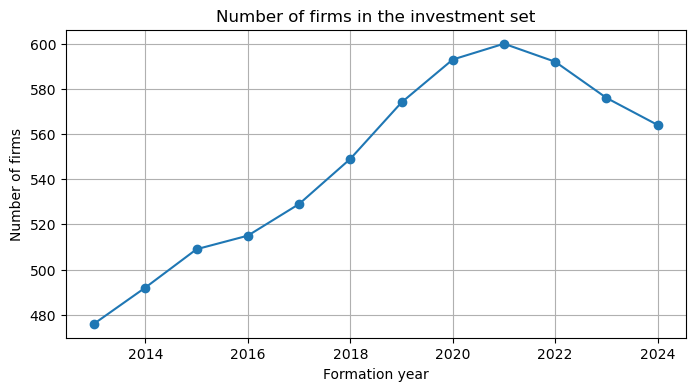

Formation year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Investment set,476,492,509,515,529,549,574,593,600,592,576,564


In [167]:
#Investment-set summary table
investment_set_summary = pd.DataFrame(investment_set_summary)

#Plot investment-set size over time
plt.figure(figsize=(8, 4))
plt.plot(
    investment_set_summary["Formation year"],
    investment_set_summary["Investment set"],
    marker="o"
)

plt.xlabel("Formation year")
plt.ylabel("Number of firms")
plt.title("Number of firms in the investment set")
plt.grid(True)
plt.show()

#Display investment-set summary table
investment_set_summary_h = investment_set_summary.set_index("Formation year").T

display(
    investment_set_summary_h.style.set_table_styles([
        {"selector": "th", "props": [("font-weight", "normal")]}
    ])
)

The investment set grows until 2021 and then declines slightly, remaining above its 2013 level.

In [168]:
#Display return window for firms included in a selected formation year
def display_return_window(Y):
    return_window = return_windows[Y]

    print(f"Return window for {Y}: {return_window.shape[0]} firms x {return_window.shape[1]} months")
    return pd.concat([return_window.head(3), return_window.tail(3)])

display_return_window(2013)

Return window for 2013: 476 firms x 120 months


,,2004-01-30,2004-02-27,2004-03-31,2004-04-30,2004-05-31,2004-06-30,2004-07-30,2004-08-31,2004-09-30,2004-10-29,...,2013-03-29,2013-04-30,2013-05-31,2013-06-28,2013-07-31,2013-08-30,2013-09-30,2013-10-31,2013-11-29,2013-12-31
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.088928,0.026638,-0.066856,-0.026994,0.082812,-0.042959,0.165459,0.054922,0.116077,-0.000440
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.100846,0.037526,-0.031482,-0.148959,0.100742,0.128355,-0.043392,0.123908,0.003055,-0.043559
AT0000652011,ERSTE GROUP BANK,0.046667,0.079814,0.071706,-0.000052,0.044817,0.016728,-0.011124,-0.020587,0.094143,0.066647,...,-0.135031,0.124498,0.051145,-0.179389,0.143278,0.054999,-0.011263,0.116744,-0.001007,-0.010583
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,-0.004957,-0.038398,0.059788,-0.055193,0.035784,0.002706,-0.089871,-0.068871,0.036248,-0.048216,...,0.120372,0.119668,-0.117930,0.039357,0.218692,-0.039334,0.094488,0.034864,0.177968,-0.009896
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.104047,0.040237,-0.026080,-0.028397,0.075428,0.015613,-0.118468,-0.078985,-0.047269,0.002395,...,0.063283,-0.032764,0.000188,0.028465,0.015303,-0.034766,-0.008992,-0.015608,0.101876,-0.014022
US91822M5022,VEON ADR 1:25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.004201,0.011997,-0.091324,0.011039,-0.004963,0.071968,0.095055,0.224596,-0.115793,0.053706


In [169]:
display_return_window(2024)

Return window for 2024: 564 firms x 120 months


,,2015-01-30,2015-02-27,2015-03-31,2015-04-30,2015-05-29,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.007497,0.083381,-0.067453,0.043248,0.022085,-0.042154,0.094490,0.015036,-0.092876,0.026422,...,0.108443,0.011546,0.033131,-0.000733,0.003180,0.036136,-0.035440,-0.059676,0.035909,0.003256
AT00000VIE62,FLUGHAFEN WIEN,-0.067870,-0.006604,0.010007,0.031179,0.021555,-0.033702,0.000286,0.054234,-0.014691,0.050992,...,0.008014,-0.010005,-0.008850,0.046773,0.017577,0.090889,-0.058220,0.007093,-0.012423,-0.026907
AT0000606306,RAIFFEISEN BANK INTL.,-0.226446,0.290598,-0.076573,0.201255,-0.086194,-0.052879,0.010778,-0.079761,-0.033372,0.215296,...,-0.042459,-0.004103,-0.011563,-0.053651,0.121057,0.017364,0.005357,-0.101859,0.089128,0.048898
US0528001094,AUTOLIV,-0.000572,0.065833,0.046829,0.008078,0.067296,-0.074524,-0.098931,-0.023764,0.067152,0.112188,...,0.043873,-0.005317,0.070744,-0.161321,-0.054682,0.013147,-0.082610,-0.005252,0.067185,-0.046960
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,-0.009328,0.005047,0.095223,-0.028001,-0.003497,-0.014778,0.170047,-0.064925,-0.121411,0.050865,...,0.073001,-0.004252,0.204982,-0.040164,0.072613,0.082617,-0.045045,0.023308,-0.090022,0.313469
US91822M5022,VEON ADR 1:25,-0.137988,0.522433,-0.043706,0.082006,0.095342,-0.199647,0.162720,-0.192044,-0.118699,-0.081477,...,-0.078995,0.020468,0.037249,0.021179,0.026150,0.001757,0.140351,0.052308,0.060673,0.181254


This cell computes the demeaned return windows and the corresponding sample covariance matrices used as inputs for the Ledoit-Wolf shrinkage:

In [170]:
#Build expected returns, demeaned return windows and sample covariance matrices
expected_returns_dict = {}
demeaned_returns_dict = {}
sample_cov_dict = {}

for Y in years:
    #Return window for eligible firms
    return_window = return_windows[Y]

    #Expected returns as average returns over available observations
    avg_returns = return_window.mean(axis=1)

    #Demeaned returns
    demeaned_returns = return_window.sub(avg_returns, axis=0)

    #Missing demeaned returns are set to zero
    demeaned_returns = demeaned_returns.fillna(0.0)

    #Sample covariance matrix
    T = demeaned_returns.shape[1]
    sample_cov = demeaned_returns @ demeaned_returns.T / T

    #Store expected returns, demeaned returns and sample covariance matrix
    expected_returns_dict[Y] = avg_returns
    demeaned_returns_dict[Y] = demeaned_returns
    sample_cov_dict[Y] = sample_cov

In [171]:
#Display demeaned return window for a selected formation year
def display_demeaned_window(Y):
    demeaned_returns = demeaned_returns_dict[Y]

    print(f"Demeaned return window for {Y}: {demeaned_returns.shape[0]} firms x {demeaned_returns.shape[1]} months")
    return pd.concat([demeaned_returns.head(3), demeaned_returns.tail(3)])


display_demeaned_window(2013)

Demeaned return window for 2013: 476 firms x 120 months


,,2004-01-30,2004-02-27,2004-03-31,2004-04-30,2004-05-31,2004-06-30,2004-07-30,2004-08-31,2004-09-30,2004-10-29,...,2013-03-29,2013-04-30,2013-05-31,2013-06-28,2013-07-31,2013-08-30,2013-09-30,2013-10-31,2013-11-29,2013-12-31
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.088586,0.026980,-0.066514,-0.026652,0.083154,-0.042617,0.165801,0.055264,0.116419,-0.000098
AT0000606306,RAIFFEISEN BANK INTL.,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.110056,0.028316,-0.040693,-0.158169,0.091531,0.119144,-0.052602,0.114697,-0.006156,-0.052769
AT0000652011,ERSTE GROUP BANK,0.033546,0.066693,0.058585,-0.013173,0.031696,0.003607,-0.024245,-0.033708,0.081022,0.053526,...,-0.148152,0.111377,0.038024,-0.192510,0.130157,0.041878,-0.024384,0.103623,-0.014128,-0.023704
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,-0.016884,-0.050325,0.047861,-0.067121,0.023856,-0.009222,-0.101799,-0.080799,0.024320,-0.060143,...,0.108444,0.107740,-0.129858,0.027430,0.206765,-0.051262,0.082560,0.022937,0.166040,-0.021824
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.098599,0.034789,-0.031529,-0.033846,0.069980,0.010164,-0.123917,-0.084434,-0.052718,-0.003053,...,0.057834,-0.038212,-0.005261,0.023017,0.009855,-0.040215,-0.014440,-0.021057,0.096427,-0.019470
US91822M5022,VEON ADR 1:25,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.009963,0.006235,-0.097086,0.005277,-0.010725,0.066206,0.089292,0.218834,-0.121555,0.047943


In [172]:
display_demeaned_window(2024)

Demeaned return window for 2024: 564 firms x 120 months


,,2015-01-30,2015-02-27,2015-03-31,2015-04-30,2015-05-29,2015-06-30,2015-07-31,2015-08-31,2015-09-30,2015-10-30,...,2024-03-29,2024-04-30,2024-05-31,2024-06-28,2024-07-31,2024-08-30,2024-09-30,2024-10-31,2024-11-29,2024-12-31
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,-0.006140,0.069744,-0.081091,0.029611,0.008448,-0.055791,0.080852,0.001399,-0.106513,0.012785,...,0.094806,-0.002091,0.019494,-0.014371,-0.010457,0.022498,-0.049078,-0.073313,0.022272,-0.010381
AT00000VIE62,FLUGHAFEN WIEN,-0.079148,-0.017882,-0.001271,0.019900,0.010277,-0.044980,-0.010992,0.042956,-0.025969,0.039714,...,-0.003264,-0.021283,-0.020128,0.035495,0.006299,0.079610,-0.069498,-0.004185,-0.023701,-0.038185
AT0000606306,RAIFFEISEN BANK INTL.,-0.237491,0.279554,-0.087617,0.190210,-0.097239,-0.063923,-0.000266,-0.090806,-0.044417,0.204252,...,-0.053503,-0.015148,-0.022608,-0.064695,0.110013,0.006319,-0.005688,-0.112903,0.078083,0.037853
US0528001094,AUTOLIV,-0.008953,0.057451,0.038448,-0.000304,0.058915,-0.082905,-0.107313,-0.032145,0.058771,0.103807,...,0.035491,-0.013698,0.062363,-0.169702,-0.063063,0.004766,-0.090991,-0.013633,0.058803,-0.055341
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,-0.011529,0.002846,0.093022,-0.030202,-0.005698,-0.016979,0.167846,-0.067126,-0.123612,0.048664,...,0.070800,-0.006453,0.202781,-0.042365,0.070412,0.080416,-0.047246,0.021107,-0.092223,0.311268
US91822M5022,VEON ADR 1:25,-0.147022,0.513399,-0.052741,0.072971,0.086307,-0.208682,0.153686,-0.201078,-0.127733,-0.090511,...,-0.088029,0.011434,0.028215,0.012144,0.017115,-0.007277,0.131317,0.043273,0.051638,0.172220


In [173]:
#Display sample covariance matrix for a selected formation year
def display_sample_covariance(Y):
    sample_cov = sample_cov_dict[Y]

    print(f"Sample covariance matrix for {Y}: {sample_cov.shape[0]} firms x {sample_cov.shape[1]} firms")
    return pd.concat([sample_cov.head(3), sample_cov.tail(3)])


display_sample_covariance(2013)

Sample covariance matrix for 2013: 476 firms x 476 firms


,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059,AT0000746409,BE0003470755,BE0003565737,BE0003593044,BE0003735496,...,SE0015811955,SE0015812219,SE0016589188,SE0017486889,SE0018012494,SE0018012635,SE0020050417,US70211M1099,US8816242098,US91822M5022
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV,VERBUND,SOLVAY,KBC GROUP,COFINIMMO,ORANGE BELGIUM,...,INVESTOR A,SWEDISH MATCH DEAD - DELIST.02/01/23,ELECTROLUX B,ATLAS COPCO A,MODERN TIMES GROUP MTG B,WIHLBORGS FASTIGHETER,BOLIDEN ORD SHS,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,VEON ADR 1:25
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.012218,0.009658,0.011238,0.004263,0.005672,0.005790,0.005242,0.011731,0.003264,0.002436,...,0.004696,0.002494,0.005125,0.005660,0.007870,0.004216,0.008909,0.002724,0.000321,0.000948
AT0000606306,RAIFFEISEN BANK INTL.,0.009658,0.017680,0.015351,0.004950,0.007581,0.007266,0.007452,0.015713,0.004379,0.002624,...,0.006559,0.003786,0.006946,0.007431,0.009791,0.005165,0.012989,0.002846,0.001187,0.001654
AT0000652011,ERSTE GROUP BANK,0.011238,0.015351,0.020110,0.005028,0.007348,0.008238,0.008964,0.017764,0.004408,0.002781,...,0.007423,0.003740,0.008412,0.007480,0.010442,0.004628,0.013300,0.004803,0.001364,0.001808
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,0.002724,0.002846,0.004803,0.001712,0.002995,0.003225,0.003219,0.003959,0.001743,0.001118,...,0.002819,0.001309,0.003777,0.003088,0.004923,0.002143,0.004284,0.010107,0.001867,0.002125
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.000321,0.001187,0.001364,0.000818,0.001120,0.000736,0.000548,0.001389,0.000298,0.000262,...,0.001020,0.000412,0.002079,0.000942,0.001587,0.000245,0.002452,0.001867,0.003039,0.000472
US91822M5022,VEON ADR 1:25,0.000948,0.001654,0.001808,0.000462,0.001610,0.000935,0.001981,0.001964,0.000707,0.001292,...,0.001443,0.000437,0.001693,0.001523,0.001971,0.000660,0.001831,0.002125,0.000472,0.004198


In [174]:
display_sample_covariance(2024)

Sample covariance matrix for 2024: 564 firms x 564 firms


,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008,AT0000730007,AT0000743059,AT0000746409,AT0000831706,AT0000908504,...,SE0015961909,SE0015988019,SE0016589188,SE0017486889,SE0018012494,SE0018012635,SE0020050417,US0528001094,US8816242098,US91822M5022
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,ANDRITZ,OMV,VERBUND,WIENERBERGER,VIENNA INSURANCE GROUP A,...,HEXAGON B,NIBE INDUSTRIER,ELECTROLUX B,ATLAS COPCO A,MODERN TIMES GROUP MTG B,WIHLBORGS FASTIGHETER,BOLIDEN ORD SHS,AUTOLIV,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,VEON ADR 1:25
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.004674,0.002653,0.003718,0.003584,0.001419,0.002942,0.003749,0.003083,0.003278,0.001975,...,0.002971,0.003010,0.002801,0.002124,0.003153,0.002408,0.003196,0.003411,0.003079,0.002793
AT00000VIE62,FLUGHAFEN WIEN,0.002653,0.005941,0.003380,0.003456,0.001459,0.002490,0.003625,0.002793,0.002008,0.002248,...,0.002185,0.002222,0.002035,0.001278,0.002334,0.001099,0.002199,0.002591,0.000358,0.002487
AT0000606306,RAIFFEISEN BANK INTL.,0.003718,0.003380,0.012730,0.007979,0.003106,0.005527,0.006871,0.003017,0.006179,0.004221,...,0.004811,0.004047,0.005496,0.004567,0.004280,0.003917,0.005620,0.006610,0.002671,0.007343
US0528001094,AUTOLIV,0.003411,0.002591,0.006610,0.005330,0.001295,0.004256,0.004631,0.003066,0.006008,0.003457,...,0.004599,0.004595,0.004815,0.004057,0.003753,0.003169,0.004449,0.009394,0.004147,0.003823
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.003079,0.000358,0.002671,0.004236,0.000244,0.003709,0.002721,0.001087,0.003771,0.002594,...,0.003340,0.003030,0.002380,0.002373,0.003530,0.002582,0.002041,0.004147,0.016627,0.003381
US91822M5022,VEON ADR 1:25,0.002793,0.002487,0.007343,0.007475,0.002961,0.005074,0.005581,0.003684,0.004995,0.003423,...,0.005074,0.005123,0.004075,0.005003,0.001463,0.004244,0.004475,0.003823,0.003381,0.028125


This cell builds the constant-correlation target from the sample covariance matrix:

In [175]:
def constant_correlation_target(sample_cov):
    #Sample covariance matrix
    sample_cov_values = sample_cov.to_numpy(dtype=float)

    #Standard deviations
    std = np.sqrt(np.diag(sample_cov_values))

    #Correlation matrix implied by the sample covariance matrix
    corr = sample_cov_values / np.outer(std, std)

    #Exclude diagonal correlations from the average
    np.fill_diagonal(corr, 0.0)

    #Average off-diagonal correlation
    N = sample_cov_values.shape[0]
    common_corr = corr.sum() / (N * (N - 1))

    #Constant-correlation target
    target_cov_values = common_corr * np.outer(std, std)

    #Keep sample variances on the diagonal
    np.fill_diagonal(target_cov_values, np.diag(sample_cov_values))

    return target_cov_values, common_corr

This cell computes the shrinkage intensity used to combine the sample covariance matrix and the constant-correlation target:

In [176]:
def compute_shrinkage_intensity(demeaned_returns, sample_cov, target_cov_values):
    #Demeaned returns and sample covariance matrix
    demeaned_values = demeaned_returns.to_numpy(dtype=float)
    sample_cov_values = sample_cov.to_numpy(dtype=float)

    #Matrix dimensions
    N, T = demeaned_values.shape

    #Squared demeaned returns
    demeaned_squared = demeaned_values ** 2

    #Estimate pi
    phi_mat = (demeaned_squared @ demeaned_squared.T) / T - sample_cov_values ** 2
    pi = phi_mat.sum()

    #Simplified rho term
    rho = np.trace(phi_mat) / N

    #Squared Frobenius distance between sample covariance and target
    gamma = np.linalg.norm(sample_cov_values - target_cov_values, "fro") ** 2

    #Shrinkage intensity
    kappa = (pi - rho) / gamma
    shrinkage_intensity = max(0.0, min(1.0, kappa / T))

    return shrinkage_intensity

This cell applies the Ledoit-Wolf shrinkage using the demeaned returns and the sample covariance matrix already computed:

In [177]:
def ledoit_wolf_constant_correlation(demeaned_returns, sample_cov):
    #Sample covariance matrix
    sample_cov_values = sample_cov.to_numpy(dtype=float)

    #Constant-correlation target
    target_cov_values, common_corr = constant_correlation_target(sample_cov)

    #Shrinkage intensity
    shrinkage_intensity = compute_shrinkage_intensity(
        demeaned_returns,
        sample_cov,
        target_cov_values
    )

    #Final shrunk covariance matrix
    shrunk_cov_values = (
        (1.0 - shrinkage_intensity) * sample_cov_values
        + shrinkage_intensity * target_cov_values
    )

    return shrunk_cov_values, target_cov_values, shrinkage_intensity, common_corr

This cell applies Ledoit-Wolf shrinkage and stores the resulting covariance matrices: 

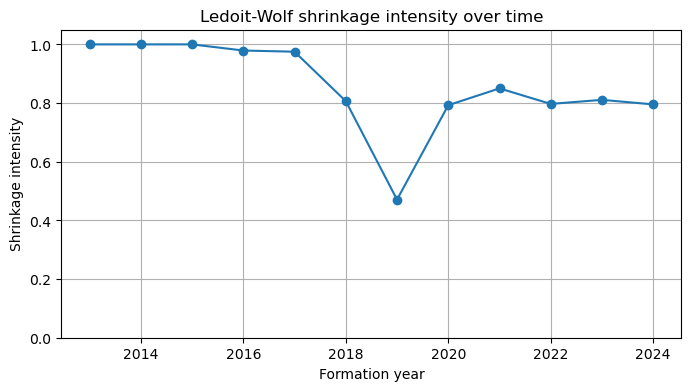

Formation year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Shrinkage intensity,1.000000,1.000000,1.000000,0.979085,0.975059,0.806481,0.470794,0.792689,0.849989,0.797102,0.810919,0.795410


In [178]:
target_cov_dict = {}
shrunk_cov_dict = {}
shrinkage_intensity_dict = {}
common_corr_dict = {}

lw_summary = []

for Y in years:
    #Demeaned returns and sample covariance matrix
    demeaned_returns = demeaned_returns_dict[Y]
    sample_cov = sample_cov_dict[Y]

    #Ledoit-Wolf shrinkage
    shrunk_cov_values, target_cov_values, shrinkage_intensity, common_corr = ledoit_wolf_constant_correlation(
        demeaned_returns,
        sample_cov
    )

    #Firm index
    firms = sample_cov.index

    #Store target and final covariance matrix
    target_cov_dict[Y] = pd.DataFrame(target_cov_values, index=firms, columns=firms)
    shrunk_cov_dict[Y] = pd.DataFrame(shrunk_cov_values, index=firms, columns=firms)

    #Store scalars
    shrinkage_intensity_dict[Y] = shrinkage_intensity
    common_corr_dict[Y] = common_corr

    #Summary row
    lw_summary.append({
        "Formation year": Y,
        "Shrinkage intensity": shrinkage_intensity,
    })

lw_summary = pd.DataFrame(lw_summary)

#Plot shrinkage intensity over time
plt.figure(figsize=(8, 4))
plt.plot(
    lw_summary["Formation year"],
    lw_summary["Shrinkage intensity"],
    marker="o"
)

plt.xlabel("Formation year")
plt.ylabel("Shrinkage intensity")
plt.title("Ledoit-Wolf shrinkage intensity over time")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

#Display Ledoit-Wolf summary table
lw_summary_h = lw_summary.set_index("Formation year").T

display(
    lw_summary_h.style.set_table_styles([
        {"selector": "th", "props": [("font-weight", "normal")]}
    ])
)

In [179]:
#Display Ledoit-Wolf covariance matrix for a selected formation year
def display_lw_covariance(Y):
    lw_cov = shrunk_cov_dict[Y]

    print(f"Ledoit-Wolf covariance matrix for {Y}: {lw_cov.shape[0]} firms x {lw_cov.shape[1]} firms")
    return pd.concat([lw_cov.head(3), lw_cov.tail(3)])


display_lw_covariance(2013)

Ledoit-Wolf covariance matrix for 2013: 476 firms x 476 firms


,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059,AT0000746409,BE0003470755,BE0003565737,BE0003593044,BE0003735496,...,SE0015811955,SE0015812219,SE0016589188,SE0017486889,SE0018012494,SE0018012635,SE0020050417,US70211M1099,US8816242098,US91822M5022
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV,VERBUND,SOLVAY,KBC GROUP,COFINIMMO,ORANGE BELGIUM,...,INVESTOR A,SWEDISH MATCH DEAD - DELIST.02/01/23,ELECTROLUX B,ATLAS COPCO A,MODERN TIMES GROUP MTG B,WIHLBORGS FASTIGHETER,BOLIDEN ORD SHS,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,VEON ADR 1:25
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.012218,0.006224,0.006638,0.003995,0.004875,0.004584,0.004125,0.007736,0.002509,0.003369,...,0.003552,0.002959,0.004949,0.004318,0.006201,0.003796,0.008051,0.004706,0.002581,0.003033
AT0000606306,RAIFFEISEN BANK INTL.,0.006224,0.017680,0.007985,0.004805,0.005865,0.005515,0.004962,0.009306,0.003018,0.004052,...,0.004273,0.003559,0.005954,0.005194,0.007460,0.004567,0.009685,0.005661,0.003104,0.003648
AT0000652011,ERSTE GROUP BANK,0.006638,0.007985,0.020110,0.005125,0.006255,0.005882,0.005292,0.009925,0.003219,0.004322,...,0.004557,0.003796,0.006350,0.005540,0.007956,0.004871,0.010329,0.006037,0.003311,0.003891
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,0.004706,0.005661,0.006037,0.003633,0.004434,0.004170,0.003752,0.007036,0.002282,0.003064,...,0.003231,0.002691,0.004502,0.003927,0.005640,0.003453,0.007323,0.010107,0.002347,0.002758
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.002581,0.003104,0.003311,0.001992,0.002432,0.002287,0.002057,0.003858,0.001251,0.001680,...,0.001772,0.001476,0.002469,0.002154,0.003093,0.001894,0.004016,0.002347,0.003039,0.001513
US91822M5022,VEON ADR 1:25,0.003033,0.003648,0.003891,0.002342,0.002858,0.002687,0.002418,0.004535,0.001471,0.001975,...,0.002082,0.001734,0.002901,0.002531,0.003635,0.002225,0.004719,0.002758,0.001513,0.004198


In [180]:
display_lw_covariance(2024)

Ledoit-Wolf covariance matrix for 2024: 564 firms x 564 firms


,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008,AT0000730007,AT0000743059,AT0000746409,AT0000831706,AT0000908504,...,SE0015961909,SE0015988019,SE0016589188,SE0017486889,SE0018012494,SE0018012635,SE0020050417,US0528001094,US8816242098,US91822M5022
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,ANDRITZ,OMV,VERBUND,WIENERBERGER,VIENNA INSURANCE GROUP A,...,HEXAGON B,NIBE INDUSTRIER,ELECTROLUX B,ATLAS COPCO A,MODERN TIMES GROUP MTG B,WIHLBORGS FASTIGHETER,BOLIDEN ORD SHS,AUTOLIV,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,VEON ADR 1:25
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,0.004674,0.002099,0.003039,0.002771,0.001415,0.002357,0.002733,0.002471,0.002559,0.001715,...,0.002381,0.002779,0.002453,0.002023,0.002747,0.002268,0.002753,0.002655,0.003233,0.003957
AT00000VIE62,FLUGHAFEN WIEN,0.002099,0.005941,0.003260,0.003005,0.001567,0.002488,0.002958,0.002646,0.002539,0.001937,...,0.002446,0.002894,0.002535,0.002052,0.002847,0.002226,0.002816,0.002736,0.003008,0.004326
AT0000606306,RAIFFEISEN BANK INTL.,0.003039,0.003260,0.012730,0.004996,0.002492,0.004027,0.004650,0.003654,0.004380,0.003026,...,0.003911,0.004399,0.004226,0.003555,0.004345,0.003730,0.004613,0.004582,0.004843,0.007090
US0528001094,AUTOLIV,0.002655,0.002736,0.004582,0.003980,0.001860,0.003359,0.003735,0.003236,0.003906,0.002565,...,0.003455,0.004007,0.003650,0.003082,0.003748,0.003165,0.003886,0.009394,0.004539,0.005582
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.003233,0.003008,0.004843,0.004711,0.002172,0.004069,0.004265,0.003693,0.004332,0.003002,...,0.004028,0.004701,0.004032,0.003481,0.004687,0.003876,0.004376,0.004539,0.016627,0.007077
US91822M5022,VEON ADR 1:25,0.003957,0.004326,0.007090,0.006529,0.003365,0.005344,0.005965,0.005268,0.005653,0.003915,...,0.005389,0.006355,0.005444,0.004919,0.005456,0.005222,0.006064,0.005582,0.007077,0.028125


The vector of expected returns is computed as the firm-level average returns used to demean the formation window: 

In [181]:
#Expected returns for 2013
expected_returns_2013 = (
    expected_returns_dict[2013]
    .rename("Expected return")
    .reset_index()
)

pd.concat([expected_returns_2013.head(3), expected_returns_2013.tail(3)])

,ISIN,NAME,Expected return
0,AT000000STR1,STRABAG SE,-0.000342
1,AT0000606306,RAIFFEISEN BANK INTL.,0.009210
2,AT0000652011,ERSTE GROUP BANK,0.013121
473,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,0.011928
474,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.005449
475,US91822M5022,VEON ADR 1:25,0.005762


In [182]:
#Expected returns for 2024
expected_returns_2024 = (
    expected_returns_dict[2024]
    .rename("Expected return")
    .reset_index()
)

pd.concat([expected_returns_2024.head(3), expected_returns_2024.tail(3)])

,ISIN,NAME,Expected return
0,AT000000STR1,STRABAG SE,0.013637
1,AT00000VIE62,FLUGHAFEN WIEN,0.011278
2,AT0000606306,RAIFFEISEN BANK INTL.,0.011045
561,US0528001094,AUTOLIV,0.008381
562,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,0.002201
563,US91822M5022,VEON ADR 1:25,0.009034


#### **2.2) Minimum variance portfolio**

The minimum-variance portfolio is constructed out of sample, with weights estimated at the end of year Y and applied to year Y+1.

The portfolio is rebalanced annually from December 2013 to December 2024, producing a monthly series of ex-post returns from 2014 to 2025.

We then compute the characteristics of this portfolio. 

This cell defines the optimizer used to compute the long-only minimum-variance weights: 

In [183]:
#Define the long-only minimum-variance optimizer
def solve_minvar(cov_matrix):
    #Number of assets
    n = cov_matrix.shape[0]

    #If only one asset is available, assign full weight to it
    if n == 1:
        return pd.Series([1.0], index=cov_matrix.index)

    #Convert the covariance matrix to a NumPy array
    Sigma = cov_matrix.to_numpy(dtype=float)

    #Initial guess: equally weighted portfolio
    x0 = np.repeat(1.0 / n, n)

    #Portfolio variance objective
    def objective(w):
        return float(w @ Sigma @ w)

    #Gradient of the portfolio variance
    def objective_grad(w):
        return 2.0 * Sigma @ w

    #Fully invested portfolio constraint
    constraints = [{
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0,
        "jac": lambda w: np.ones_like(w)
    }]

    #Long-only bounds
    bounds = [(0.0, 1.0)] * n

    #Numerical optimization
    res = minimize(
        objective,
        x0=x0,
        jac=objective_grad,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-9, "disp": False}
    )

    #Stop if the optimizer fails
    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    #Store weights as a pandas Series
    weights = pd.Series(res.x, index=cov_matrix.index)

    #Normalize weights for numerical precision
    weights = weights / weights.sum()

    return weights

This cell loads and formats the monthly risk-free rate used to compute the Sharpe ratio:

In [184]:
#Load risk-free rate
rf = pd.read_csv(path + "RF.csv", sep=";", na_values="N/A")

#Format dates and RF values
rf.columns = ["date_code", "RF"]

rf["date_code"] = rf["date_code"].astype(str).str.strip()
rf["date"] = pd.to_datetime(rf["date_code"], format="%Y%m") + pd.offsets.MonthEnd(0)

rf["RF"] = pd.to_numeric(
    rf["RF"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
) / 100.0

rf_series = rf.set_index("date")["RF"].sort_index()

This cell computes the minimum-variance weights at the end of each formation year and applies them to monthly out-of-sample returns:

In [185]:
#Minimum-variance portfolio returns
mv_weights = {}
oos_rows = []

for Y in years:
    #Minimum-variance weights at the end of year Y
    cov_matrix = shrunk_cov_dict[Y]
    weights = solve_minvar(cov_matrix)

    mv_weights[Y] = weights

    #Monthly out-of-sample returns in year Y+1
    oos_months = sorted([d for d in returns_wide.columns if d.year == Y + 1])

    current_weights = weights.copy()

    for date in oos_months:
        #Asset returns for the current month
        asset_returns = returns_wide.loc[current_weights.index, date]

        #Keep assets with observed returns
        valid = asset_returns.notna()
        asset_returns = asset_returns[valid]
        month_weights = current_weights[valid]

        if len(month_weights) == 0:
            oos_rows.append({
                "date": date,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        #Normalize observed weights
        month_weights = month_weights / month_weights.sum()

        #Portfolio return
        portfolio_return = float((month_weights * asset_returns).sum())

        oos_rows.append({
            "date": date,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": portfolio_return
        })

        #Passive weight update within the year
        current_weights = month_weights * (1.0 + asset_returns) / (1.0 + portfolio_return)
        current_weights = current_weights / current_weights.sum()

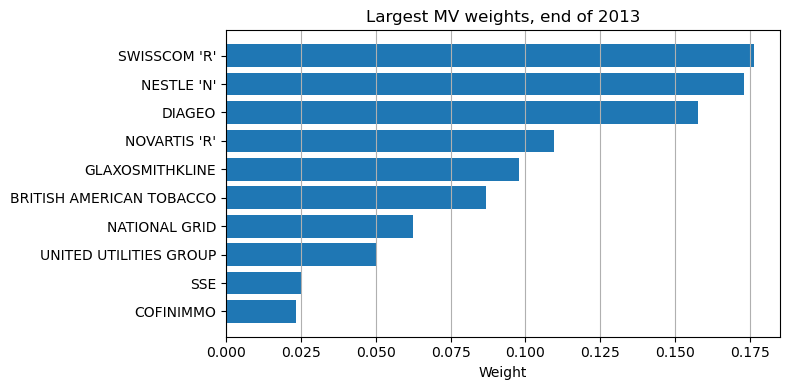

In [186]:
#Largest minimum-variance weights at the end of 2013
weights_2013 = mv_weights[2013].rename("Weight").reset_index()

weights_2013_top = (
    weights_2013
    .sort_values("Weight", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.barh(weights_2013_top["NAME"], weights_2013_top["Weight"])

plt.xlabel("Weight")
plt.ylabel("")
plt.title("Largest MV weights, end of 2013")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

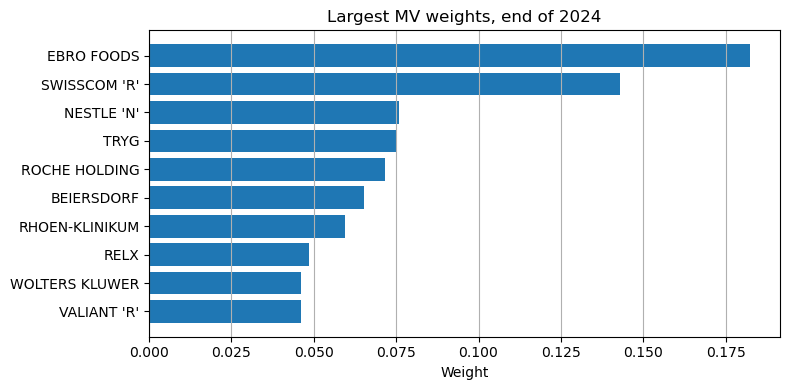

In [187]:
#Largest minimum-variance weights at the end of 2024
weights_2024 = mv_weights[2024].rename("Weight").reset_index()

weights_2024_top = (
    weights_2024
    .sort_values("Weight", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.barh(weights_2024_top["NAME"], weights_2024_top["Weight"])

plt.xlabel("Weight")
plt.ylabel("")
plt.title("Largest MV weights, end of 2024")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

This cell stores the out-of-sample return series and computes the performance statistics:

In [188]:
#Monthly out-of-sample return series
minvar_monthly_returns = pd.DataFrame(oos_rows).sort_values("date").reset_index(drop=True)

minvar_monthly_returns["date"] = pd.to_datetime(minvar_monthly_returns["date"])

minvar_monthly_returns = minvar_monthly_returns[
    (minvar_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (minvar_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

minvar_monthly_returns["cumulative_index"] = (
    1.0 + minvar_monthly_returns["portfolio_return"]
).cumprod()

mv_oos_returns = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index()

#Monthly return and risk-free alignment
monthly_returns = mv_oos_returns.dropna()

r_month = monthly_returns.copy()
r_month.index = r_month.index.to_period("M")

rf_month = rf_series.copy()
rf_month.index = rf_month.index.to_period("M")

rf_aligned = rf_month.reindex(r_month.index)

#Performance statistics
excess_returns = r_month - rf_aligned

ann_mean = 12.0 * r_month.mean()
ann_vol = np.sqrt(12.0) * r_month.std(ddof=1)
sharpe = np.sqrt(12.0) * excess_returns.mean() / excess_returns.std(ddof=1)

summary_stats = pd.DataFrame({
    "Metric": [
        "Annualized average return",
        "Annualized volatility",
        "Sharpe ratio",
        "Minimum monthly return",
        "Maximum monthly return",
        "Final cumulative index",
        "Number of monthly observations"
    ],
    "Value": [
        ann_mean,
        ann_vol,
        sharpe,
        monthly_returns.min(),
        monthly_returns.max(),
        minvar_monthly_returns["cumulative_index"].iloc[-1],
        int(monthly_returns.notna().sum())
    ]
})

summary_stats

,Metric,Value
0,Annualized average return,0.057506
1,Annualized volatility,0.135724
2,Sharpe ratio,0.294701
3,Minimum monthly return,-0.117242
4,Maximum monthly return,0.103611
5,Final cumulative index,1.782797
6,Number of monthly observations,144.000000


#### **2.3) Comparison with the value-weighted portfolio**

This section compares the properties of the out-of-sample minimum-variance portfolio with those of the value-weighted portfolio, used as the benchmark.

This cell loads the monthly market capitalization data and converts it into wide numeric format: 

In [189]:
#Load monthly market capitalization data
mv_m = pd.read_csv(path + "MV_M_cleaned.csv", sep=";", na_values="N/A")

#Convert date labels to datetime format
date_labels = mv_m.columns[2:].astype(str).str.strip()
mv_dates = pd.to_datetime(date_labels, format="%d/%m/%Y", errors="coerce")

#Create market capitalization wide panel
mv_m_wide = mv_m.copy()
mv_m_wide.columns = ["NAME", "ISIN"] + list(mv_dates.date)

#Set firm identifiers and sort dates
mv_m_wide = mv_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

#Convert monthly market capitalization values to numeric format
mv_m_wide = mv_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

This cell computes the value-weighted portfolio weights using previous-month market capitalizations: 

In [190]:
#Value-weighted portfolio weights
vw_weights = {}
vw_weight_dates = {}

return_months = sorted([d for d in returns_wide.columns if pd.notna(d)])
market_cap_months = sorted([d for d in mv_m_wide.columns if pd.notna(d)])

for Y in years:
    #Eligible firms for formation year Y
    eligible = (
        investment_sets[Y]
        .intersection(returns_wide.index)
        .intersection(mv_m_wide.index)
    )

    #Monthly out-of-sample returns in year Y+1
    oos_months = [d for d in return_months if d.year == Y + 1]

    for return_date in oos_months:
        #Previous available market-cap month used to compute weights
        weight_dates = [d for d in market_cap_months if d < return_date]

        if len(weight_dates) == 0:
            continue

        weight_date = max(weight_dates)

        #Market capitalizations at the weight date
        market_caps = mv_m_wide.loc[eligible, weight_date]

        #Keep firms with valid market capitalization
        valid_caps = (
            market_caps.notna()
            & np.isfinite(market_caps)
            & (market_caps > 0)
        )

        market_caps = market_caps[valid_caps]

        if len(market_caps) > 0:
            vw_weights[return_date] = market_caps / market_caps.sum()
            vw_weight_dates[return_date] = weight_date

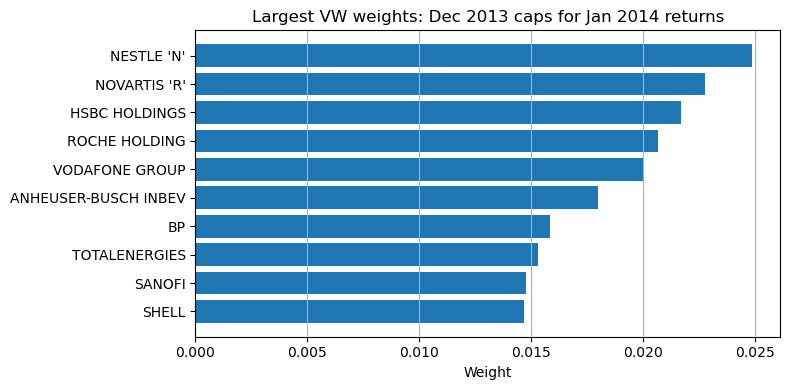

In [191]:
#Largest value-weighted weights for the first return month of 2014
return_date_2014 = min([d for d in vw_weights.keys() if d.year == 2014])
weight_date_2013 = vw_weight_dates[return_date_2014]

vw_weights_2013 = vw_weights[return_date_2014].rename("Weight").reset_index()

vw_weights_2013_top = (
    vw_weights_2013
    .sort_values("Weight", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.barh(vw_weights_2013_top["NAME"], vw_weights_2013_top["Weight"])

plt.xlabel("Weight")
plt.ylabel("")
plt.title(f"Largest VW weights: {weight_date_2013:%b %Y} caps for {return_date_2014:%b %Y} returns")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

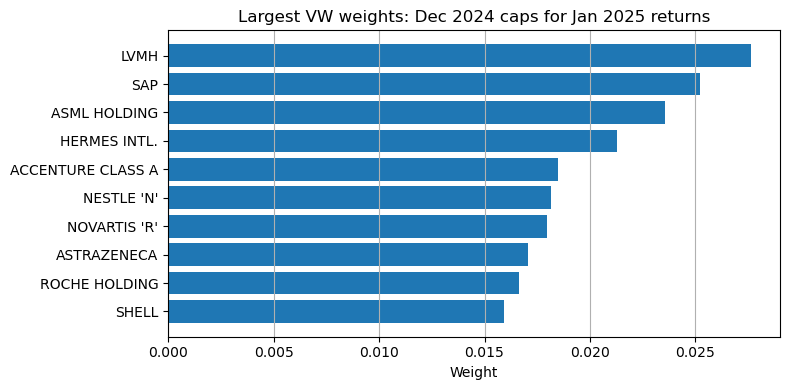

In [192]:
#Largest value-weighted weights for the first return month of 2025
return_date_2025 = min([d for d in vw_weights.keys() if d.year == 2025])
weight_date_2024 = vw_weight_dates[return_date_2025]

vw_weights_2024 = vw_weights[return_date_2025].rename("Weight").reset_index()

vw_weights_2024_top = (
    vw_weights_2024
    .sort_values("Weight", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.barh(vw_weights_2024_top["NAME"], vw_weights_2024_top["Weight"])

plt.xlabel("Weight")
plt.ylabel("")
plt.title(f"Largest VW weights: {weight_date_2024:%b %Y} caps for {return_date_2025:%b %Y} returns")
plt.gca().invert_yaxis()
plt.grid(axis="x")
plt.tight_layout()
plt.show()

This cell applies the value-weighted weights to monthly returns from the Return Index: 

In [193]:
#Value-weighted benchmark returns
vw_rows = []

for return_date, weights in vw_weights.items():
    #Monthly returns from the Return Index
    asset_returns = returns_wide.loc[weights.index, return_date]

    #Keep firms with observed returns
    valid_returns = asset_returns.notna() & np.isfinite(asset_returns)

    asset_returns = asset_returns[valid_returns]
    month_weights = weights[valid_returns]

    if len(month_weights) == 0:
        portfolio_return = np.nan
    else:
        month_weights = month_weights / month_weights.sum()
        portfolio_return = float((month_weights * asset_returns).sum())

    vw_rows.append({
        "date": return_date,
        "portfolio_return": portfolio_return
    })

This cell stores the monthly value-weighted benchmark return series: 

In [194]:
#Monthly value-weighted returns
vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

vw_monthly_returns["date"] = pd.to_datetime(vw_monthly_returns["date"])

vw_monthly_returns = vw_monthly_returns[
    (vw_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw_monthly_returns["cumulative_index"] = (
    1.0 + vw_monthly_returns["portfolio_return"]
).cumprod()

vw_oos_returns = vw_monthly_returns.set_index("date")["portfolio_return"].sort_index()

This cell compares the cumulative performance and summary statistics of the minimum-variance portfolio and the value-weighted benchmark: 

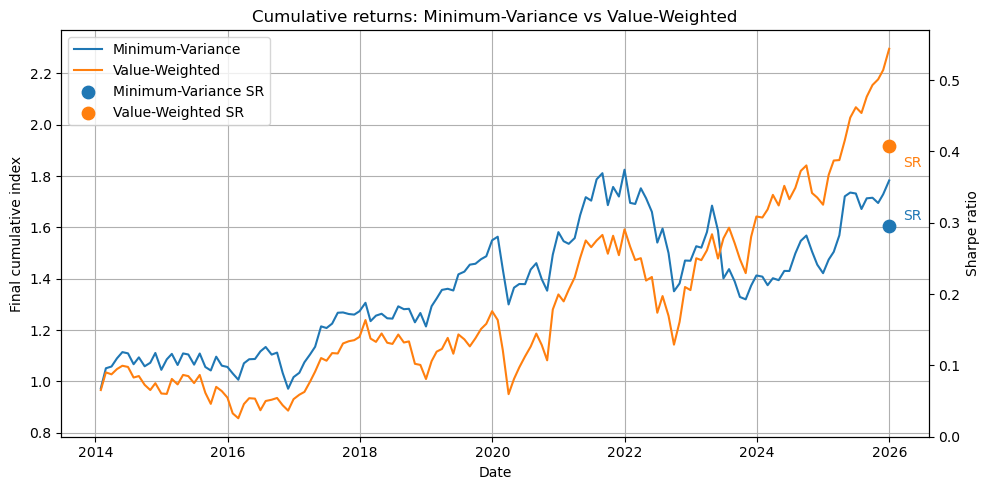

,Annualized average return,Annualized volatility,Sharpe ratio,Minimum monthly return,Maximum monthly return,Final cumulative index,Number of monthly observations
Minimum-Variance,0.057506,0.135724,0.294701,-0.117242,0.103611,1.782797,144.0
Value-Weighted,0.081951,0.158815,0.406875,-0.152972,0.182849,2.295540,144.0


In [195]:
#Combine minimum-variance and value-weighted returns
comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        vw_oos_returns.rename("Value-Weighted")
    ],
    axis=1
).sort_index()

#Cumulative return indices
comparison_cumulative = (1.0 + comparison_returns).cumprod()


#Performance statistics
def performance_stats(returns, rf_series):
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()

    r_month = returns.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf_series.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    excess_returns = r_month - rf_aligned

    ann_mean = 12.0 * r_month.mean()
    ann_vol = np.sqrt(12.0) * r_month.std(ddof=1)
    sharpe = np.sqrt(12.0) * excess_returns.mean() / excess_returns.std(ddof=1)

    cumulative_index = (1.0 + returns).cumprod()

    return pd.Series({
        "Annualized average return": ann_mean,
        "Annualized volatility": ann_vol,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": returns.min(),
        "Maximum monthly return": returns.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Number of monthly observations": int(returns.notna().sum())
    })


comparison_stats = pd.concat(
    [
        performance_stats(comparison_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        performance_stats(comparison_returns["Value-Weighted"], rf_series).rename("Value-Weighted")
    ],
    axis=1
).T


#Plot cumulative return indices and Sharpe ratios
fig, ax1 = plt.subplots(figsize=(10, 5))

line_mv, = ax1.plot(
    comparison_cumulative.index,
    comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)

line_vw, = ax1.plot(
    comparison_cumulative.index,
    comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

ax1.set_title("Cumulative returns: Minimum-Variance vs Value-Weighted")
ax1.set_xlabel("Date")
ax1.set_ylabel("Final cumulative index")
ax1.grid(True)

#Secondary axis for Sharpe ratios
ax2 = ax1.twinx()

last_date = comparison_cumulative.index[-1]

sharpe_mv = comparison_stats.loc["Minimum-Variance", "Sharpe ratio"]
sharpe_vw = comparison_stats.loc["Value-Weighted", "Sharpe ratio"]

ax2.scatter(
    last_date,
    sharpe_mv,
    color=line_mv.get_color(),
    s=80,
    label="Minimum-Variance SR"
)

ax2.scatter(
    last_date,
    sharpe_vw,
    color=line_vw.get_color(),
    s=80,
    label="Value-Weighted SR"
)

ax2.set_ylabel("Sharpe ratio")
ax2.set_ylim(0, max(sharpe_mv, sharpe_vw) * 1.4)

ax2.annotate(
    "SR",
    xy=(last_date, sharpe_mv),
    xytext=(10, 5),
    textcoords="offset points",
    color=line_mv.get_color()
)

ax2.annotate(
    "SR",
    xy=(last_date, sharpe_vw),
    xytext=(10, -15),
    textcoords="offset points",
    color=line_vw.get_color()
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

display(comparison_stats)

The value-weighted benchmark outperforms over 2014–2025, with a higher annualized return, Sharpe ratio, and final cumulative index.

The minimum-variance portfolio is less profitable but smoother, in line with its risk-minimization objective.

### Interpretation of the results

The value-weighted portfolio delivers a higher annualized return and a higher Sharpe ratio than the minimum-variance portfolio over the **2014–2025** out-of-sample period. However, this improved performance comes with higher volatility and larger drawdowns.

By construction, the minimum-variance portfolio focuses on reducing total portfolio risk, which results in a smoother return path and smaller downside shocks. This can be observed in the lower annualized volatility and the smaller minimum monthly return compared to the value-weighted benchmark.

Overall, the results highlight the classic trade-off between risk reduction and return generation: while the minimum-variance strategy produces more stable returns, the value-weighted portfolio captures a larger share of market upside during the sample period.

## **Part II - Portfolio Allocation with Carbon Emission Reduction**


## 3) Allocation with a 50% Reduction in Carbon Emissions

### 3.1) Carbon Emissions

In [ ]:
# Revenues and carbon intensity

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Required objects from previous sections
required_objects = [
    "years",
    "co2_panel"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

years_list = list(years)

# Load annual revenues
rev_raw = pd.read_csv("../data/cleaned/REVENUE_Y_cleaned.csv", sep=";")

rev_panel = rev_raw.copy()
rev_panel.columns = ["NAME", "ISIN"] + list(pd.to_numeric(rev_raw.columns[2:]).astype(int))
rev_panel = rev_panel.set_index(["ISIN", "NAME"])

rev_panel = rev_panel.apply(
    lambda x: pd.to_numeric(
        x.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

# Align revenue panel to the firms available in co2_panel
rev_panel = rev_panel.reindex(co2_panel.index)

# Carbon intensity = CO2 emissions / revenues in million USD
# Revenue is divided by 1000 because the cleaned revenue series is assumed to be in thousand USD.
CI = co2_panel[years_list] / (rev_panel[years_list] / 1000.0)
CI = CI.replace([np.inf, -np.inf], np.nan)

display(CI[[2013, 2014, 2023, 2024]])

In [ ]:
# Market cap at the end of each formation year and E / Cap

required_objects = [
    "years",
    "year_end_dec",
    "co2_panel",
    "mv_panel"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

years_list = list(years)

# Market cap at the end of each formation year
MCap = pd.DataFrame({
    Y: mv_panel[year_end_dec[Y]].reindex(co2_panel.index)
    for Y in years_list
})

# E / Cap = emissions / market capitalization at the end of each formation year
E_to_Cap = co2_panel[years_list] / MCap[years_list]
E_to_Cap = E_to_Cap.replace([np.inf, -np.inf], np.nan)

display(E_to_Cap[[2013, 2014, 2023, 2024]])

In [ ]:
# Carbon metrics for the minimum-variance and value-weighted portfolios

required_objects = [
    "years",
    "investment_sets",
    "mv_weights",
    "MCap",
    "CI",
    "E_to_Cap"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")

portfolio_carbon = []

for Y in years:

    eligible = investment_sets[Y]

    # Minimum-variance weights from Section 2.2
    alpha_mv = mv_weights[Y].reindex(eligible).fillna(0.0)

    # Value-weighted benchmark weights at the formation date
    caps_y = MCap[Y].reindex(eligible)
    valid_caps = caps_y.notna() & np.isfinite(caps_y) & (caps_y > 0)

    alpha_vw = pd.Series(0.0, index=eligible)

    if valid_caps.sum() > 0:
        alpha_vw.loc[valid_caps] = caps_y.loc[valid_caps] / caps_y.loc[valid_caps].sum()

    # Carbon variables
    CI_y = CI[Y].reindex(eligible)
    E_to_Cap_y = E_to_Cap[Y].reindex(eligible)

    portfolio_carbon.append({
        "formation_year": Y,
        "WACI_MV": (alpha_mv * CI_y).sum(skipna=True),
        "WACI_VW": (alpha_vw * CI_y).sum(skipna=True),
        "CF_MV": (alpha_mv * E_to_Cap_y).sum(skipna=True),
        "CF_VW": (alpha_vw * E_to_Cap_y).sum(skipna=True)
    })

portfolio_carbon = pd.DataFrame(portfolio_carbon)

portfolio_carbon_table = portfolio_carbon.set_index("formation_year").T

display(portfolio_carbon_table)

In [ ]:
# Plot WACI
portfolio_carbon.set_index("formation_year")[["WACI_MV", "WACI_VW"]].plot(
    figsize=(10, 5),
    marker="o",
    title="Weighted Average Carbon Intensity"
)

plt.xlabel("Formation year")
plt.ylabel("tCO2e / million USD revenues")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Plot CF
portfolio_carbon.set_index("formation_year")[["CF_MV", "CF_VW"]].plot(
    figsize=(10, 5),
    marker="o",
    title="Carbon Footprint"
)

plt.xlabel("Formation year")
plt.ylabel("tCO2e / million USD invested")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# WACI drivers over all years
waci_drivers = []

for Y in years:
    eligible = investment_sets[Y]

    alpha_mv = mv_weights[Y].reindex(eligible).fillna(0)

    caps_y = mv_panel[year_end_dec[Y]].reindex(eligible)
    caps_y = caps_y[caps_y.notna() & (caps_y > 0)]
    alpha_vw = (caps_y / caps_y.sum()).reindex(eligible).fillna(0)

    df = pd.DataFrame({
        "formation_year": Y,
        "alpha_mv": alpha_mv,
        "alpha_vw": alpha_vw,
        "CI": CI[Y].reindex(eligible)
    }).reset_index()

    df["WACI_contribution_MV"] = df["alpha_mv"] * df["CI"]
    df["WACI_contribution_VW"] = df["alpha_vw"] * df["CI"]

    waci_drivers.append(df)

waci_drivers = pd.concat(waci_drivers, ignore_index=True)

def plot_top10_waci(metric, title):
    top10 = (
        waci_drivers
        .groupby(["ISIN", "NAME"])[metric]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    plot_data = (
        waci_drivers
        .set_index(["ISIN", "NAME"])
        .loc[top10]
        .reset_index()
        .pivot_table(
            index="formation_year",
            columns="NAME",
            values=metric,
            aggfunc="sum"
        )
    )

    plot_data.plot(figsize=(12, 6), marker="o")
    plt.title(title)
    plt.xlabel("Formation year")
    plt.ylabel("WACI contribution")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_top10_waci("WACI_contribution_MV", "Top 10 WACI Drivers Over Time - Minimum-Variance")
plot_top10_waci("WACI_contribution_VW", "Top 10 WACI Drivers Over Time - Value-Weighted")

The WACI drivers show that the minimum-variance portfolio is more dependent on a few carbon-intensive firms than the value-weighted benchmark. The early-sample spikes are mainly driven by EVRAZ, whereas the value-weighted benchmark spreads its exposure across several large high-emission firms, with Holcim standing out as one of the main contributors.

### 3.2) Long-only portfolio with a carbon footprint objective

In [ ]:
def solve_minvar_carbon(cov_matrix, carbon_vector, carbon_limit):
    n = cov_matrix.shape[0]

    Sigma = cov_matrix.to_numpy(dtype=float) + ridge * np.eye(n)
    c = carbon_vector.to_numpy(dtype=float)

    x0 = np.repeat(1 / n, n)

    def objective(w):
        return float(w @ Sigma @ w)

    constraints = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "ineq", "fun": lambda w: carbon_limit - np.sum(w * c)}
    ]

    bounds = [(0, 1)] * n

    res = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False}
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    return w / w.sum()

In [ ]:
mv50_weights = {}

for Y in years:
    eligible = investment_sets[Y]

    Sigma = sigma_dict[Y].copy()
    Sigma = Sigma.loc[Sigma.index.intersection(eligible), Sigma.columns.intersection(eligible)]

    carbon_y = E_to_Cap[Y].reindex(Sigma.index)

    valid_assets = Sigma.index[
        Sigma.notna().all(axis=1)
        & carbon_y.notna()
        & np.isfinite(carbon_y)
        & (carbon_y >= 0)
    ]

    Sigma = Sigma.loc[valid_assets, valid_assets]
    carbon_y = carbon_y.loc[valid_assets]

    carbon_limit = 0.5 * portfolio_carbon.loc[
        portfolio_carbon["formation_year"] == Y,
        "CF_MV"
    ].iloc[0]

    mv50_weights[Y] = solve_minvar_carbon(
        cov_matrix=Sigma,
        carbon_vector=carbon_y,
        carbon_limit=carbon_limit
    )

In [ ]:
mv50_check = []

for Y in years:
    alpha_mv50 = mv50_weights[Y]
    carbon_y = E_to_Cap[Y].reindex(alpha_mv50.index)

    mv50_check.append({
        "formation_year": Y,
        "CF_MV50": (alpha_mv50 * carbon_y).sum()
    })

mv50_check = pd.DataFrame(mv50_check)

mv50_check_table = mv50_check.set_index("formation_year").T

mv50_check_table

In [ ]:
mv50_rows = []

for Y in years:
    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])

    if len(oos_months) == 0:
        continue

    current_weights = mv50_weights[Y].copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        forced_delist_assets = []

        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = r_t.notna() & current_weights.notna()

        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            mv50_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        mv50_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        denom = 1 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1 + r_t) / denom
            current_weights = current_weights / current_weights.sum()
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )

mv50_monthly_returns = pd.DataFrame(mv50_rows).sort_values("date").reset_index(drop=True)

mv50_monthly_returns["date"] = pd.to_datetime(mv50_monthly_returns["date"])

mv50_monthly_returns = mv50_monthly_returns[
    (mv50_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (mv50_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

mv50_monthly_returns["cumulative_index"] = (
    1 + mv50_monthly_returns["portfolio_return"]
).cumprod()

mv50_oos_returns = mv50_monthly_returns.set_index("date")["portfolio_return"].sort_index()

pd.concat([
    mv50_monthly_returns[["date", "portfolio_return", "cumulative_index"]].head(3),
    mv50_monthly_returns[["date", "portfolio_return", "cumulative_index"]].tail(3)
])

In [ ]:
# Combine minimum-variance and minimum-variance 50% CF returns
mv50_comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        mv50_oos_returns.rename("Minimum-Variance 50% CF")
    ],
    axis=1
).sort_index()

# Cumulative returns
mv50_comparison_cumulative = (1.0 + mv50_comparison_returns).cumprod()

# Plot cumulative performance comparison
plt.figure(figsize=(10, 5))

plt.plot(
    mv50_comparison_cumulative.index,
    mv50_comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)

plt.plot(
    mv50_comparison_cumulative.index,
    mv50_comparison_cumulative["Minimum-Variance 50% CF"],
    label="Minimum-Variance 50% CF"
)

plt.title("Cumulative returns: Minimum-Variance vs Minimum-Variance 50% CF")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.ylim(0.8, 2.3)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1
    return drawdown.min()


def portfolio_stats(r, rf):
    r = r.replace([np.inf, -np.inf], np.nan).dropna()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned
    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": 12 * r.mean(),
        "Annualized volatility": np.sqrt(12) * r.std(ddof=1),
        "Sharpe ratio": np.sqrt(12) * excess.mean() / excess.std(ddof=1),
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })


mv50_summary_stats = pd.concat(
    [
        portfolio_stats(
            mv50_comparison_returns["Minimum-Variance"],
            rf_series
        ).rename("Minimum-Variance"),

        portfolio_stats(
            mv50_comparison_returns["Minimum-Variance 50% CF"],
            rf_series
        ).rename("Minimum-Variance 50% CF")
    ],
    axis=1
).T

print("Done.")

print("\nReturn series check:")
print("MV start:   ", mv50_comparison_returns["Minimum-Variance"].dropna().index.min())
print("MV end:     ", mv50_comparison_returns["Minimum-Variance"].dropna().index.max())
print("MV50 start: ", mv50_comparison_returns["Minimum-Variance 50% CF"].dropna().index.min())
print("MV50 end:   ", mv50_comparison_returns["Minimum-Variance 50% CF"].dropna().index.max())
print("Number of months:", mv50_comparison_returns.shape[0])

print("\nSummary statistics:")
print(mv50_summary_stats.to_string())

In [ ]:
# WACI and CF for the carbon-constrained minimum-variance portfolio
mv50_carbon = []

for Y in years:
    eligible = investment_sets[Y]

    alpha_mv50 = mv50_weights[Y].reindex(eligible).fillna(0)

    CI_y = CI[Y].reindex(eligible)
    E_to_Cap_y = E_to_Cap[Y].reindex(eligible)

    mv50_carbon.append({
        "formation_year": Y,
        "WACI_MV50": (alpha_mv50 * CI_y).sum(),
        "CF_MV50": (alpha_mv50 * E_to_Cap_y).sum()
    })

mv50_carbon = pd.DataFrame(mv50_carbon)

mv50_carbon = mv50_carbon.merge(
    portfolio_carbon[["formation_year", "WACI_MV", "CF_MV"]],
    on="formation_year",
    how="left"
)

mv50_carbon_table = mv50_carbon.set_index("formation_year").T

mv50_carbon_table

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    mv50_carbon["formation_year"],
    mv50_carbon["WACI_MV"],
    marker="o",
    label="Minimum-Variance"
)

plt.plot(
    mv50_carbon["formation_year"],
    mv50_carbon["WACI_MV50"],
    marker="o",
    label="Minimum-Variance 50% CF"
)

plt.title("WACI: Minimum-Variance vs Minimum-Variance 50% CF")
plt.xlabel("Formation year")
plt.ylabel("tCO2e / million USD revenues")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    mv50_carbon["formation_year"],
    mv50_carbon["CF_MV"],
    marker="o",
    label="Minimum-Variance"
)

plt.plot(
    mv50_carbon["formation_year"],
    mv50_carbon["CF_MV50"],
    marker="o",
    label="Minimum-Variance 50% CF"
)

plt.title("Carbon Footprint: Minimum-Variance vs Minimum-Variance 50% CF")
plt.xlabel("Formation year")
plt.ylabel("tCO2e / million USD invested")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Top 5 weight changes caused by the 50% CF constraint
weight_changes = []

for Y in years:
    eligible = investment_sets[Y]

    alpha_mv = mv_weights[Y].reindex(eligible).fillna(0)
    alpha_mv50 = mv50_weights[Y].reindex(eligible).fillna(0)

    df = pd.DataFrame({
        "formation_year": Y,
        "alpha_MV": alpha_mv,
        "alpha_MV50": alpha_mv50
    }).reset_index()

    df["change"] = df["alpha_MV50"] - df["alpha_MV"]
    df["abs_change"] = df["change"].abs()

    weight_changes.append(df)

weight_changes = pd.concat(weight_changes, ignore_index=True)

top5_changes = (
    weight_changes
    .groupby(["ISIN", "NAME"])["abs_change"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plot_changes = (
    weight_changes
    .set_index(["ISIN", "NAME"])
    .loc[top5_changes]
    .reset_index()
)

plot_changes["firm_label"] = plot_changes["NAME"] + " (" + plot_changes["ISIN"] + ")"

plot_changes = plot_changes.pivot_table(
    index="formation_year",
    columns="firm_label",
    values="change",
    aggfunc="sum"
) * 100

plt.figure(figsize=(12, 6))

for firm in plot_changes.columns:
    plt.plot(plot_changes.index, plot_changes[firm], marker="o", label=firm)

plt.axhline(0, linewidth=1)
plt.title("Largest Portfolio Weight Changes Due to the 50% Carbon Footprint Constraint")
plt.xlabel("Formation year")
plt.ylabel("Weight change in percentage points (MV50 - MV)")
plt.grid(True, alpha=0.3)
plt.legend(title="Firm", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

The composition changes show that the 50% carbon footprint constraint mainly affects the firms with the largest weight adjustments. EVRAZ and National Grid are often reduced, consistent with their relatively high carbon footprint contribution. At the same time, the constrained portfolio reallocates weight toward firms such as Chubb, Coloplast, and Perrigo. Overall, the constraint does not simply reduce all weights proportionally, but reshapes the portfolio by reducing selected carbon-intensive exposures and increasing other positions.

### 3.3) Tracking error minimization

In [ ]:
def solve_tracking_error_carbon(cov_matrix, benchmark_weights, carbon_vector, carbon_limit):
    n = cov_matrix.shape[0]

    Sigma = cov_matrix.to_numpy(dtype=float) + ridge * np.eye(n)
    b = benchmark_weights.to_numpy(dtype=float)
    c = carbon_vector.to_numpy(dtype=float)

    carbon_b = float(b @ c)

    if carbon_b <= carbon_limit:
        return benchmark_weights / benchmark_weights.sum()

    if carbon_limit < c.min() - 1e-12:
        raise ValueError("Carbon constraint infeasible.")

    j = np.argmin(c)

    x_low = np.zeros(n)
    x_low[j] = 1.0

    carbon_low = c[j]

    lam = (carbon_limit - carbon_low) / (carbon_b - carbon_low)
    lam = np.clip(lam, 0, 1)

    x0 = lam * b + (1 - lam) * x_low

    def objective(w):
        diff = w - b
        return float(diff @ Sigma @ diff)

    def gradient(w):
        return 2 * Sigma @ (w - b)

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1,
            "jac": lambda w: np.ones_like(w)
        },
        {
            "type": "eq",
            "fun": lambda w: np.sum(w * c) - carbon_limit,
            "jac": lambda w: c
        }
    ]

    bounds = [(0, 1)] * n

    res = minimize(
        objective,
        x0=x0,
        jac=gradient,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False}
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    return w / w.sum()

In [ ]:
vw50_weights = {}

for Y in years:
    print("Solving year:", Y)

    eligible = investment_sets[Y]

    Sigma = sigma_dict[Y].copy()
    Sigma = Sigma.loc[
        Sigma.index.intersection(eligible),
        Sigma.columns.intersection(eligible)
    ]

    caps_y = mv_panel[year_end_dec[Y]].reindex(Sigma.index)
    caps_y = caps_y[caps_y.notna() & (caps_y > 0)]

    alpha_vw = (caps_y / caps_y.sum()).reindex(Sigma.index).fillna(0)

    carbon_y = E_to_Cap[Y].reindex(Sigma.index)

    valid_assets = Sigma.index[
        Sigma.notna().all(axis=1)
        & carbon_y.notna()
        & np.isfinite(carbon_y)
        & (carbon_y >= 0)
    ]

    Sigma = Sigma.loc[valid_assets, valid_assets]
    carbon_y = carbon_y.loc[valid_assets]

    alpha_vw = alpha_vw.loc[valid_assets]
    alpha_vw = alpha_vw / alpha_vw.sum()

    carbon_limit = 0.5 * portfolio_carbon.loc[
        portfolio_carbon["formation_year"] == Y,
        "CF_VW"
    ].iloc[0]

    vw50_weights[Y] = solve_tracking_error_carbon(
        cov_matrix=Sigma,
        benchmark_weights=alpha_vw,
        carbon_vector=carbon_y,
        carbon_limit=carbon_limit
    )

In [ ]:
vw50_check = []

for Y in years:
    alpha_vw50 = vw50_weights[Y]
    carbon_y = E_to_Cap[Y].reindex(alpha_vw50.index)

    vw50_check.append({
        "formation_year": Y,
        "CF_VW50": (alpha_vw50 * carbon_y).sum()
    })

vw50_check = pd.DataFrame(vw50_check)

vw50_check_table = vw50_check.set_index("formation_year").T

vw50_check_table

In [ ]:
vw50_check = []

for Y in years:
    alpha_vw50 = vw50_weights[Y]
    carbon_y = E_to_Cap[Y].reindex(alpha_vw50.index)

    cf_vw50 = (alpha_vw50 * carbon_y).sum()

    cf_vw = portfolio_carbon.loc[
        portfolio_carbon["formation_year"] == Y,
        "CF_VW"
    ].iloc[0]

    vw50_check.append({
        "formation_year": Y,
        "CF_VW": cf_vw,
        "CF_VW50": cf_vw50,
        "carbon_limit": 0.5 * cf_vw,
        "difference": cf_vw50 - 0.5 * cf_vw
    })

vw50_check = pd.DataFrame(vw50_check)

vw50_check.set_index("formation_year").T

In [ ]:
vw50_rows = []

for Y in years:
    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])

    if len(oos_months) == 0:
        continue

    current_weights = vw50_weights[Y].copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        forced_delist_assets = []

        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = r_t.notna() & current_weights.notna()

        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            vw50_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        vw50_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        denom = 1 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1 + r_t) / denom
            current_weights = current_weights / current_weights.sum()
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )

vw50_monthly_returns = pd.DataFrame(vw50_rows).sort_values("date").reset_index(drop=True)

vw50_monthly_returns["date"] = pd.to_datetime(vw50_monthly_returns["date"])

vw50_monthly_returns = vw50_monthly_returns[
    (vw50_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw50_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw50_monthly_returns["cumulative_index"] = (
    1 + vw50_monthly_returns["portfolio_return"]
).cumprod()

vw50_oos_returns = vw50_monthly_returns.set_index("date")["portfolio_return"].sort_index()

pd.concat([
    vw50_monthly_returns[["date", "portfolio_return", "cumulative_index"]].head(3),
    vw50_monthly_returns[["date", "portfolio_return", "cumulative_index"]].tail(3)
])

In [ ]:
# Combine value-weighted and value-weighted 50% CF returns
vw50_comparison_returns = pd.concat(
    [
        vw_oos_returns.rename("Value-Weighted"),
        vw50_oos_returns.rename("Value-Weighted 50% CF")
    ],
    axis=1
).sort_index()

# Cumulative returns
vw50_comparison_cumulative = (1.0 + vw50_comparison_returns).cumprod()

# Plot cumulative performance comparison
plt.figure(figsize=(10, 5))

plt.plot(
    vw50_comparison_cumulative.index,
    vw50_comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

plt.plot(
    vw50_comparison_cumulative.index,
    vw50_comparison_cumulative["Value-Weighted 50% CF"],
    label="Value-Weighted 50% CF"
)

plt.title("Cumulative returns: Value-Weighted vs Value-Weighted 50% CF")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.ylim(0.8, 2.3)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1
    return drawdown.min()


def portfolio_stats(r, rf):
    r = r.replace([np.inf, -np.inf], np.nan).dropna()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned
    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": 12 * r.mean(),
        "Annualized volatility": np.sqrt(12) * r.std(ddof=1),
        "Sharpe ratio": np.sqrt(12) * excess.mean() / excess.std(ddof=1),
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })


vw50_summary_stats = pd.concat(
    [
        portfolio_stats(
            vw50_comparison_returns["Value-Weighted"],
            rf_series
        ).rename("Value-Weighted"),

        portfolio_stats(
            vw50_comparison_returns["Value-Weighted 50% CF"],
            rf_series
        ).rename("Value-Weighted 50% CF")
    ],
    axis=1
).T

print("Done.")

print("\nReturn series check:")
print("VW start:   ", vw50_comparison_returns["Value-Weighted"].dropna().index.min())
print("VW end:     ", vw50_comparison_returns["Value-Weighted"].dropna().index.max())
print("VW50 start: ", vw50_comparison_returns["Value-Weighted 50% CF"].dropna().index.min())
print("VW50 end:   ", vw50_comparison_returns["Value-Weighted 50% CF"].dropna().index.max())
print("Number of months:", vw50_comparison_returns.shape[0])

print("\nSummary statistics:")
print(vw50_summary_stats.to_string())

### 3.4) Comparison of portfolios

In [ ]:
# 3.4 Comparison of portfolios

# Combine monthly returns
all_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        mv50_oos_returns.rename("Minimum-Variance 50% CF"),
        vw_oos_returns.rename("Value-Weighted"),
        vw50_oos_returns.rename("Value-Weighted 50% CF")
    ],
    axis=1
).sort_index()

# Cumulative returns
all_cumulative = (1 + all_returns).cumprod()

plt.figure(figsize=(10, 5))

for col in all_cumulative.columns:
    plt.plot(all_cumulative.index, all_cumulative[col], label=col)

plt.title("Cumulative Returns: Comparison of Portfolios")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.ylim(0.8, 2.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1
    return drawdown.min()


def portfolio_stats(r, rf):
    r = r.replace([np.inf, -np.inf], np.nan).dropna()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned
    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": 12 * r.mean(),
        "Annualized volatility": np.sqrt(12) * r.std(ddof=1),
        "Sharpe ratio": np.sqrt(12) * excess.mean() / excess.std(ddof=1),
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })


# Financial summary statistics
all_summary_stats = pd.concat(
    [
        portfolio_stats(all_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        portfolio_stats(all_returns["Minimum-Variance 50% CF"], rf_series).rename("Minimum-Variance 50% CF"),
        portfolio_stats(all_returns["Value-Weighted"], rf_series).rename("Value-Weighted"),
        portfolio_stats(all_returns["Value-Weighted 50% CF"], rf_series).rename("Value-Weighted 50% CF")
    ],
    axis=1
).T

print("Summary statistics:")
print(all_summary_stats.to_string())

The cumulative return comparison shows that the value-weighted portfolio delivers the strongest final performance over the sample, while the minimum-variance portfolios provide a smoother but lower-growth return path. The carbon-constrained minimum-variance portfolio performs very similarly to the standard minimum-variance portfolio, suggesting that the 50% carbon footprint constraint does not impose a large financial cost in this case.

For the value-weighted strategy, the carbon-constrained version remains close to the original benchmark but may show some performance differences due to the tracking-error constraint and the exclusion or reduction of high-carbon firms. Overall, the four-portfolio comparison highlights the main trade-off: carbon footprint can be reduced substantially, but the financial impact depends on the benchmark and on how restrictive the decarbonization constraint is.

In [ ]:
# Carbon footprint comparison across the four portfolios

carbon_comparison = portfolio_carbon[
    ["formation_year", "CF_MV", "CF_VW"]
].copy()

cf_mv50 = []
cf_vw50 = []

for Y in years:
    eligible = investment_sets[Y]

    alpha_mv50 = mv50_weights[Y].reindex(eligible).fillna(0)
    alpha_vw50 = vw50_weights[Y].reindex(eligible).fillna(0)

    E_to_Cap_y = E_to_Cap[Y].reindex(eligible)

    cf_mv50.append((alpha_mv50 * E_to_Cap_y).sum())
    cf_vw50.append((alpha_vw50 * E_to_Cap_y).sum())

carbon_comparison["CF_MV50"] = cf_mv50
carbon_comparison["CF_VW50"] = cf_vw50

plt.figure(figsize=(10, 5))

plt.plot(
    carbon_comparison["formation_year"],
    carbon_comparison["CF_MV"],
    marker="o",
    label="Minimum-Variance"
)

plt.plot(
    carbon_comparison["formation_year"],
    carbon_comparison["CF_MV50"],
    marker="o",
    label="Minimum-Variance 50% CF"
)

plt.plot(
    carbon_comparison["formation_year"],
    carbon_comparison["CF_VW"],
    marker="o",
    label="Value-Weighted"
)

plt.plot(
    carbon_comparison["formation_year"],
    carbon_comparison["CF_VW50"],
    marker="o",
    label="Value-Weighted 50% CF"
)

plt.title("Carbon Footprint: Comparison of Portfolios")
plt.xlabel("Formation year")
plt.ylabel("tCO2e / million USD invested")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The carbon footprint comparison confirms that both constrained portfolios achieve the targeted reduction relative to their respective benchmarks. The minimum-variance 50% CF portfolio cuts the carbon footprint of the standard minimum-variance portfolio by construction, while the value-weighted 50% CF portfolio does the same relative to the value-weighted benchmark.

The reduction is particularly relevant for the minimum-variance strategy, whose unconstrained carbon footprint is more volatile and affected by large spikes. Overall, the results suggest that a substantial carbon footprint reduction can be achieved without a major deterioration in financial performance over the sample.